# Crear archivo *.bin

Aunque el vivado puede crear el archivo *.bin, las diferentes versiones de vivado y las versiones del linux o el petalinux instalado en la FPGA pueden no ser compatibles, por tanto es más seguro crear el archivo *.bin desde el simbolo del sistema en windows (CMD). 
Abrimos CMD en windows en la carpeta donde generamos el bitstream (*.bit) y en un block de notas creamos el archivo download.bif y copiamos dentro:

In [ ]:
all:
{
    xadc_axiLite.bit
}

en este caso "xadc_axiLite.bit" es el nombre del bitstream generado por vivado.

# Comprobar que existe la herramienta BOOTGEN

Comprobar que existe la herramienta bootgen en windows

In [ ]:
</> cmd
bootgen -help

o

In [ ]:
</> cmd
bootgen -version

si se obtiene algo como:

"bootgen" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.

Entonces, bootgen no esta instalado o en algunas versiones de vivado, se debe cargar primero el entorno desde AMD/Xilinx Command Promp o ejecutar: 

In [ ]:
</> cmd
C:\Xilinx\Vitis\2022.2\settings64.exe

La ruta puede cambiar según la versión de Vivado. Ya en este caso se repite la comprobación de bootgen

In [ ]:
</> cmd
bootgen -help

# Ejecutar bootgen

Abrir una consola CMD donde se encuentran los archivos *.bit y download.bif y ejecutar el comando

In [ ]:
</> cmd
 bootgen -image download.bif -arch zynq -process_bitstream bin -w -o nombre_archivo.bin


****** Xilinx Bootgen v2022.2.0

  **** Build date : Oct 13 2022-12:22:51

    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.


[INFO]   : Bootimage generated successfully

Ahora en la carpeta hay un nuevo archivo nombre_archivo.bit.bin

### Renombrar el archivo

In [ ]:
</>  cmd
ren nombre_archivo.bit.bin nuevo_nombre.bin

# Copiar archivo a la ARTY
password = xilinx

</> cmd 
scp nombre_archivo.bin xilinx@IP_DE_LA_ARTY:/home/xilinx/

## Conectarse a la FPGA ARTY 

el password es xilinx

In [ ]:
</> cmd
ssh xilinx@IP_DE_LA_ARTY

En la arty, copiar el archivo *.bin al directorio /lib/firmware/

In [ ]:
</> bash (ARTY) 
sudo cp /home/xilinx/nombre_archivo.bin /lib/firmware/

# Programar la FPGA

In [ ]:
</> bash (ARTY)

echo nombre_archivo.bin | sudo tee /sys/class/fpga_manager/fpga0/firmware


### Comprobar el resultado

In [ ]:
</> bash (ARTY)

dmesg | tail -20

cat /sys/class/fpga_manager/fpga0/state

operating

## Comunicacion con la FPGA

para comunicarse con la fPGA y sus diferentes registros, debemos conocer las direcciones de los registros, en este caso el programa desarrollado solo tiene el módulo xadc conectado por un bus axiLite

            * xadc_wiz_0/S_axi_lite                  0x43C00000           64K        0x43C0FFFF

eso quiere decir que hay reservados 64K de memoria para el xadc_wiz_0 y que se encuentra entre las posiciones 0x43C00000 y 0x43C0FFFF.

Vamos a escribir un script en python que permita hacer la comunicación, pero, el script será escrito de tal forma que permita llamarlo desde LabVIEW.

## LabVIEW y Python 

No cualquier versión de LabVIEW sirve para llamar un script de python, cada version de LabVIEW tiene versiones de python con la que es compatible. así:

    *   LabVIEW 2018                        Python 2.7   3.6
    *   LabVIEW 2019                        Python 2.7   3.6   3.7
    *   LabVIEW 2020                        Python 3.6   3.7   3.8
    *   LabVIEW 2021                        Python 3.6   3.7   3.9
    *   LabVIEW 2022 Q1                     Python 3.8   3.9
    *   LabVIEW 2022 Q3                     Python 3.9
    *   LabVIEW 2023 Q1                     Python 3.9   3.10
    *   LabVIEW 2023 Q3                     Python 3.9   3.10  3.11
    *   LabVIEW 2024                        Python 3.10  3.11
    *   LabVIEW 2025                        Python 3.11  y más recientes
    
 Tambien debe coincidir la arquitectura, ambos deben tener la misma arquitectura, de 32 bits o 64 bits.
 
### Python

Ver versiones instaladas de python.

In [ ]:
</> cmd

py --list

Si es necesario, en la página oficial de python, descarga la versión que mejor se adapte a tu LabVIEW, junto con su arquitectura 32 o 64 bits.

se debe instalar paramiko, para poder hacer una comunicación SSH desde python, pero antes se debe actualizar la herramienta pip, pero en la versión donde se va a trabajar (en mi caso la version de python es 3.9 de 32 bits)

In [ ]:
</> cmd

py -3.9-32 -m pip install --ipgrade pip

Y luego instalamos paramiko

In [ ]:
</> cmd

py -3.9-32 -m pip install paramiko

Por tratarse de diferentes versiones de python puede ser que se presenten problemas al instalar paramiko, si es una versión anterior de python, es mejor tratar de instalar una version compatible de paramiko y para evitar errores, instalar una version correspondiente de cryptography, programa necesario para instalar paramiko.

### Instalar Cryptography 

Para mi caso python 3.9-32

In [ ]:
</> cmd

py -3.9-32 -m pip install "cryptography==41.0.7"

### Instalar Paramiko

In [ ]:
</> cmd

py -3.9-32 -m pip install "paramiko==3.4.0"

### Creacion del script de python

shebang, su función es indicar al sistema operativo linux que este archivo se ejecuta con el interprete Python3, por esta razón el programa se puede ejecutar solo con ./nombre_archivo.py

In [ ]:
</> python

#!/usr/bin/env python3

paramiko es la biblioteca que implementa el protocolo SSH

In [ ]:
</> python

import paramiko

Para conectarse a la ARTY el login es "xilinx" y el password es "xilinx", se definen estas variables globales

In [ ]:
</> python

USUARIO = "xilinx"
PASSWORD = "xilinx"


SSH contendrá el objeto que representa la conexión con la FPGA (None = aún no hay ninguna conexión)

In [ ]:
</> python

ssh = None

### Definicion de la función "conectar(host)"

LabVIEW accede al script de python a través de funciones, por eso el script sera un conjunto de funciones que desarrollan una tarea particular y que pueden o no retornar una variable como resultado de la tarea particular. En este caso conectar es una funcion que recibe el parametro host que es un string y representa la dirección IP donde se encuentra conectada la FPGA

In [ ]:
</> python

def conectar(host):

    global ssh

    try:

        ssh = paramiko.SSHClient()

        ssh.set_missing_host_key_policy(
            paramiko.AutoAddPolicy()
        )

        ssh.connect(
            hostname=host,
            username=USUARIO,
            password=PASSWORD,
            timeout=10
        )

        return "FPGA conectada"

    except Exception as e:

        return str(e)

global ssh          define ssh como una variable global, ssh mantiene la información de la conexión, dirección IP, puerto, usuraio, contraseña autenticada, canal SSH abierto.

ssh = paramiko.SSHClient()       se creea un objeto de la clase SSHClient, aun no se ha conectado

ssh.set_missing_host_key_policy(
        paramiko.AutoAddPolicy()
 )

SSH trabaja con criptográfias. Cuando se abre una nueva conección a un servidor, puede aparecer el siguiente mensaje:

The authenticity of host can't be established.
Are you sure?

Normalmente la respuesta es:

yes

la libreria paramiko hace lo mismo con la instruccion AutoAddPolicity()

ssh.connect(
    hostname=host,
    username=USUARIO,
    password=PASSWORD,
    timeout=10
)
 
Esta instrucción es la que abre la conexión, es similar a hacer ssh xilinx@IP_DIRECTION_FPGA
depues envía 

password: 

Y responde automatico "xilinx"

si todo es correcto la funcion devuelve una variable de string con el mensaje

"FPGA conectada"

### Funcion desconectar()


In [ ]:
</> python

def desconectar():

    global ssh

    if ssh is not None:

        ssh.close()

        ssh = None

    return "FPGA desconectada"


esta funcion desconecta la FPGA y retorna el string "FPGA desconectada"

### Funcion ejecutar(comando)

In [ ]:
</> python

def ejecutar(comando):

    global ssh

    if ssh is None:

        return "No existe conexión."

    stdin, stdout, stderr = ssh.exec_command(comando)

    salida = stdout.read().decode()

    error = stderr.read().decode()

    if error != "":

        return error

    return salida


la funcon ejecuta un comando propio de linux a través del parámetro "comando".

ejemplo


In [ ]:
</> python

ejecutar("ls")

global ssh        se refiere a la conexión ssh con la FPGA

if ssh is None:
   return "No existe conexión"

comprueba que exista una conexión ssh con la FPGA, si no hay conexión, la función retorna el string "No existe conexión"

stdin, stdout, stderr = ssh.exec_command(comando) 

La anterior línea ejecuta el comando como si el usario lo hubiera escrito en una terminal SSH, exec_command() devuelve tres objetos, stdin, stdout, stderr

#### stdin

Es la entrada estándar, escribe información al programa remoto, por ejemplo, sudo espera un password, este password se envía por stdin

#### stdout

Es la salida estándar, lo que aparece en la pantalla del terminal, ejemplo

In [ ]:
</> SSH FPGA

$ pwd

/home/xilinx

#### stderr

es la salida de errores

salida = stdout.read().decode()      

Lee la salida en bytes (stdout.read()) y luego los convierte en texto (.decode())

error = stderr.read().decode() de igual manera lee el error, si lo hubo.

if error != "":
        return error
    return salida

si existio error, la función retorna el error, si no, retorna lo que hay en salida.

### Funcion _ejecutar_python(codigo)
    

In [ ]:
</> python

def _ejecutar_python(codigo):

    global ssh

    if ssh is None:
        raise Exception("No existe conexión con la FPGA.")

    stdin, stdout, stderr = ssh.exec_command(
        "sudo -S python3 -"
    )

    #
    # enviar password
    #

    stdin.write(PASSWORD + "\n")

    #
    # enviar código Python
    #

    stdin.write(codigo)

    stdin.flush()

    stdin.channel.shutdown_write()

    salida = stdout.read().decode()

    error = stderr.read().decode()

    if error != "":

        #
        # sudo normalmente imprime el password prompt
        #

        error = error.replace(
            "[sudo] password for xilinx:",
            ""
        ).strip()

        if error != "":

            raise Exception(error)

    return salida

Es la función que le permitirá a LabVIEW ejecutar código python directamente dentro de la FPGA con permisos de admiistrador (ROOT). Gracias a ella puede aaceder a /dev/mem y, por tanto, controlar cualquier IP del diseño.

el parametro código es lo que se va a enviar a la FPGA.

global ssh

if ssh is None:
    raise Exception("No existe conexión con la FPGA.")
    
las líneas anteriores chequean que exista una comunicación SSH con la FPGA

stdin, stdout, stderr = ssh.exec_command(
    "sudo -S python3 -"
)

envia el comando "sudo -S python3 -" 

"sudo" se usa para administrar el programa como administrador

-S Normalmente sudo pide la contraseña por teclado, de esta forma la contraseña será leída desde stdin, lo mismo para python3 -

se envia "sudo -S" sudo espera Password

stdin.write(PASSWORD + "\n")

escribe el password (xilinx)

luego se escribe "python3 -" y luego se envia el codigo

stdin.write(codigo)

el signo "-" es para indicar que es un codigo, no un archivo *.py

    * También es posible crear un script de python, guardarlo en la FPGA y solo ejecutarlo desde LabVIEW usando este mismo sistema.
    
stdin.flush()    forzar el envío, python guarda temporalmente los datos eb un búffer con flush() se obliga a enviar inmediatamente todo el contenido

stdin.channel.shutdown_write()   Le indica al interprete remoto que ya se terminó de enviar el programa

salida = stdout.read().decode()
error = stderr.read().decode()

leen la salida y el error si lo hay y lo convierte a en cadena de caracteres en cualquiera de ambos casos.

if error != "":
        error = error.replace(
            "[sudo] password for xilinx:",
            ""
        ).strip()

if error != "":
    raise Exception(error)
return salida

Si no hay error retorna lo que hay en salida.

### Funcion leerRegistro(base, offset)


In [ ]:
</> python

def leerRegistro(base, offset):

    codigo = f"""
import os
import mmap
import struct

BASE={base}
OFFSET={offset}
SIZE=0x10000

fd=os.open("/dev/mem",os.O_RDWR|os.O_SYNC)

mem=mmap.mmap(
    fd,
    SIZE,
    mmap.MAP_SHARED,
    mmap.PROT_READ|mmap.PROT_WRITE,
    offset=BASE
)

mem.seek(OFFSET)

dato=struct.unpack("<I",mem.read(4))[0]

print(dato)

mem.close()
os.close(fd)
"""

    salida = _ejecutar_python(codigo)

    return int(salida.strip())


Esta funcion lee un registro en la direccion = base + offset

codigo = f"""                  """   le pasa a codigo una cadena de texto que lleva el programa de python

#### programa en python

Este es el código que será pasado al parámetro "codigo"

import os

permite acceder /dev/mem

import map

permite mapear una región de memoria física

import struct

convierte bytes en enteros

BASE={base}
OFFSET={offset}
SIZE=0x10000

define los parametros, dirección a ser leída = BASE + OFFSET

fd=os.open("/dev/mem",os.O_RDWR|os.O_SYNC)

abre "/dev/mem" , obteniendo acceso a la memoria física del ZYNQ, el resultados es fd (file descriptor)

mem=mmap.mmap(
    fd,
    SIZE,
    mmap.MAP_SHARED,
    mmap.PROT_READ|mmap.PROT_WRITE,
    offset=BASE
)

se crea una ventana de memoria, la variable mem representa esa ventana

mem.seek(OFFSET)

ir al registro, el registro leído es BASE + OFFSET

dato=struct.unpack("<I",mem.read(4))[0]

lee el registro, mem.read(4) lee un registro AXI completo (32 bits)

struct.unpack("<I",mem.read(4)) convierte esos 4 bytes en un entero de 32 bits, además, devuelve una tupla, por eso se toma el primer elemento de esa tupla [0]

dato=struct.unpack("<I",mem.read(4))[0]

mem.close()

cierra el mapeo

os.close(fd)

cierra acceso a /dev/mem

salida = _ejecutar_python(codigo)

ejecuta el programa python guardado en el parámetro "codigo"

return int(salida.strip())

Quita los saltos de línea y convierte la salida a entero, y ese dato es la sallida del programa.

### Funcion escribirRegistro(base, offset, valor)


In [ ]:
</> python

def escribirRegistro(base, offset, valor):

    codigo = f"""
import os
import mmap
import struct

BASE={base}
OFFSET={offset}
VALOR={valor}
SIZE=0x10000

fd=os.open("/dev/mem",os.O_RDWR|os.O_SYNC)

mem=mmap.mmap(
    fd,
    SIZE,
    mmap.MAP_SHARED,
    mmap.PROT_READ|mmap.PROT_WRITE,
    offset=BASE
)

mem.seek(OFFSET)

mem.write(struct.pack("<I",VALOR))

mem.close()
os.close(fd)

print("OK")
"""

    salida = _ejecutar_python(codigo)

    return salida.strip()


Funciona de forma identica a la funcion leerRegistro descrita anteriormente, la única función diferente es:

mem.write(struct.pack("<I",VALOR))

que escribe en la dirección BASE + OFFSET el valor del parámetro "VALOR"

### Funcion tomarDatos(muestras)


In [ ]:
</> python

def tomarDatos(muestras=50):

    codigo = f"""
import os
import mmap
import struct

BASE=0x43C00000
REG=0x244
SIZE=0x10000

fd=os.open("/dev/mem",os.O_RDWR|os.O_SYNC)

mem=mmap.mmap(
    fd,
    SIZE,
    mmap.MAP_SHARED,
    mmap.PROT_READ|mmap.PROT_WRITE,
    offset=BASE
)

for i in range({muestras}):

    mem.seek(REG)

    dato=struct.unpack("<I",mem.read(4))[0]

    adc=(dato>>4)&0x0FFF

    print(adc)

mem.close()

os.close(fd)
"""

    salida = _ejecutar_python(codigo)

    datos = []

    for linea in salida.splitlines():

        linea = linea.strip()

        if linea != "":

            datos.append(int(linea))

    return datos

esta función es muy parecida a las dos anteriores, en esta funcion se lee el registro 0x04C00000 + 0x0244 = 0x04C00244, que corresponde al canal A0 en la FPGA Arty. y lo hace el número de veces indicado en el parámetro "muestras"  

for i in range({muestras}):
    mem.seek(REG)
    dato=struct.unpack("<I",mem.read(4))[0]
    adc=(dato>>4)&0x0FFF
    print(adc)

print(adc) envía un número que se envía por SSH hacia el computador

salida = _ejecutar_python(codigo)

datos = []

for linea in salida.splitlines():
    linea = linea.strip()
    if linea != "":
        datos.append(int(linea))
return datos

ejecuta el programa, se separan las lineas, divide la cadena en una lista y la convierte a enteros.

# Labview

El programa en LabvIEW es muy simple, solo se debe acceder al script de python (descrito anteriormente paso por paso) a la funcion que se desea  desarrollar.

### Inicializar python

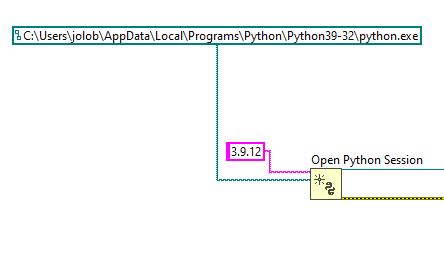

al modulo "Open python Session" se le asigna la versión del python usado, en este caso "3.9.12" y la dirección donde se encuentra la versión de python que se usará, si solo se tiene una versión de python, no es necesario pasarle la dirección.

### Conectar a la FPGA

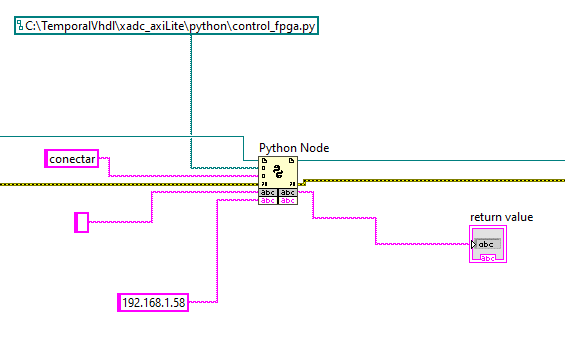

El módulo "Python Node" se encarga de llamar la funcion y pasarle los parametros necesarios.

Debe tener la ruta donde se encuentra el archivo *.py, luego el nombre de la función, en nuestro caso "conectar" a la entrada de color gris con el nombre "abc" se le conecta el tipo de variable que se espera retorne la función. la siguiente entrada son los parametros, en el caso de la función "conectar" se le debe ingresar el host (dirección IP) = "192.168.1.58". la funcion retorna la variable "return value"

### Leer los datos

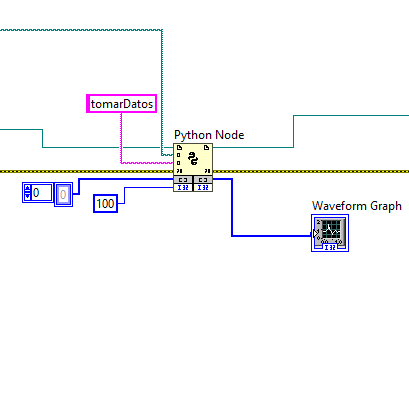

El módulo "Python Node" llama la funcion "tomarDatos" cómo parámetro se le envia la cantidad de muestras, y el tipo de variable que retorna es
un array (vector o lista) de enteros que pasan a la gráfica de labview 

#### Diagrama de bloques

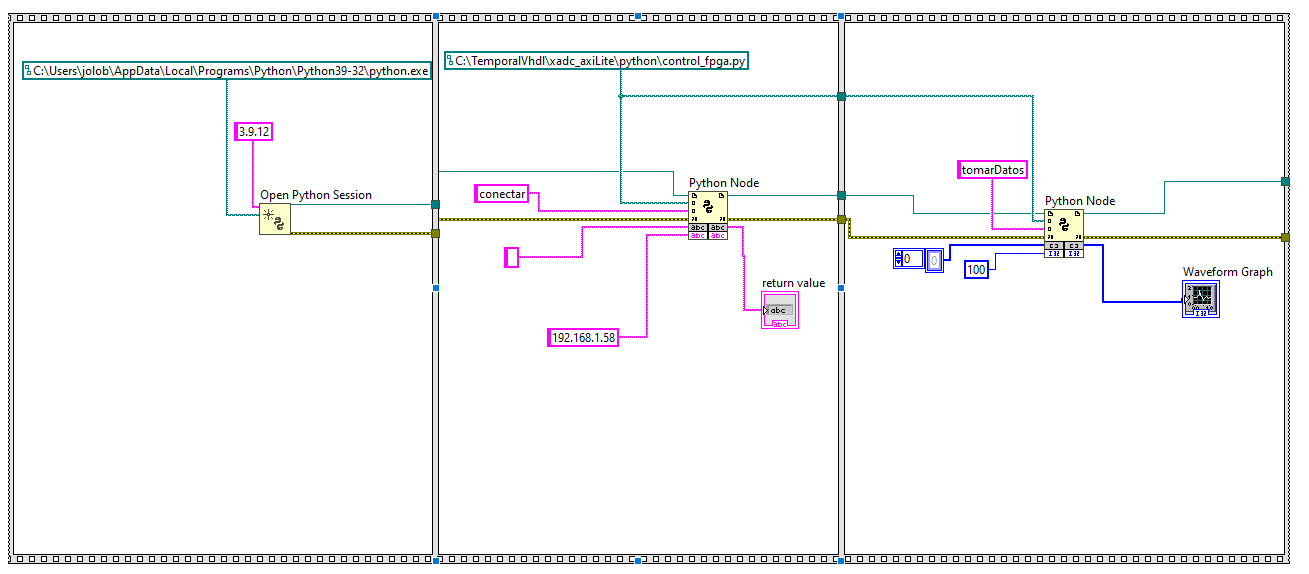

#### Panel

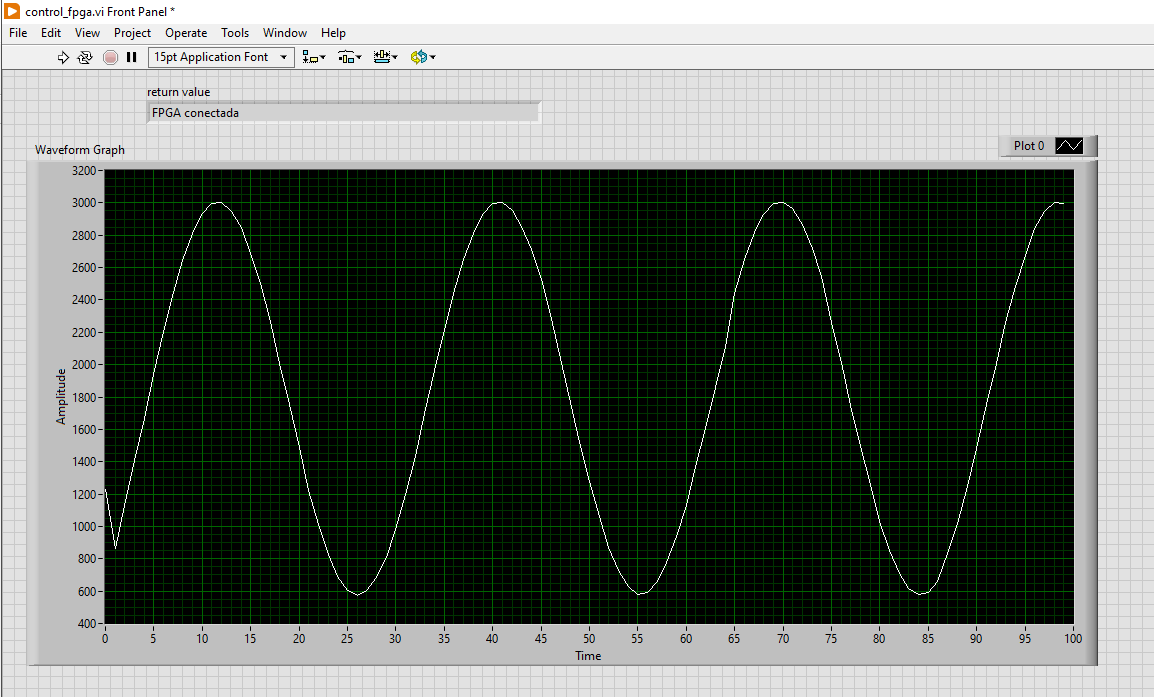



